In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from scipy import stats
import NLProcessing
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')

font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"
mpl.rcParams['svg.fonttype'] = 'none'

NT_COLORS = {
    'Acetylcholine': '#0072B2',
    'Glutamate': '#E69F00',
    'GABA': "#02DA6E",
}

In [2]:
specifiedpath = "D:\\"
filepath = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_bothresponders_Full_20260423.xlsx"
mbonlist_csv = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\MBONlist.csv"
filepath_total = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx"

df = pd.read_excel(filepath)

In [3]:
acr = df[df['responder'] == 'ACR'].set_index('MBON')
chrimson = df[df['responder'] == 'Chrimson2'].set_index('MBON')

acr = acr.drop(index=["R76B09", "VT999036"], errors="ignore")
chrimson = chrimson.drop(index=["R76B09", "VT999036"], errors="ignore")

mbons = acr.index.intersection(chrimson.index)
acr = acr.loc[mbons]
chrimson = chrimson.loc[mbons]

pref_acr = (acr['PI_Hg_OSAR'].abs() + acr['Light Attraction Index_Hg_OSAR'].abs()) / 2
pref_chr = (chrimson['PI_Hg_OSAR'].abs() + chrimson['Light Attraction Index_Hg_OSAR'].abs()) / 2

loco_acr = (acr['Log2 Bout Speed ratio_Hg_OSAR'].abs() + acr['Bout Number Index_Hg_OSAR'].abs() + acr['Bout Duration ratio_Hg_OSAR'].abs() + acr['Max Velocity ratio_Hg_OSAR'].abs()) / 4
loco_chr = (chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs() + chrimson['Bout Number Index_Hg_OSAR'].abs() + chrimson['Bout Duration ratio_Hg_OSAR'].abs() + chrimson['Max Velocity ratio_Hg_OSAR'].abs()) / 4

lobelocation = NLProcessing.generate_lobelocation(mbons.tolist(), mbonlist_csv)
lobelocation = lobelocation.set_index('MBON').loc[mbons].reset_index()

# Phenomics

## 1. Neurotransmitter separation - Preference swarm plots

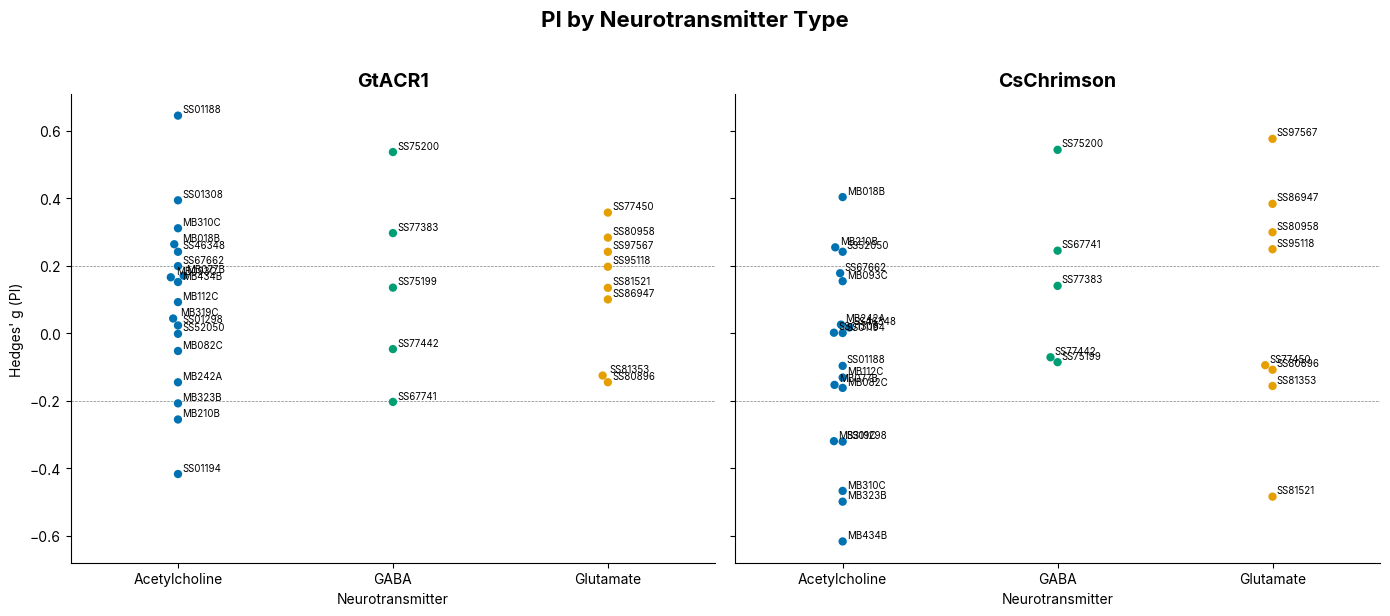

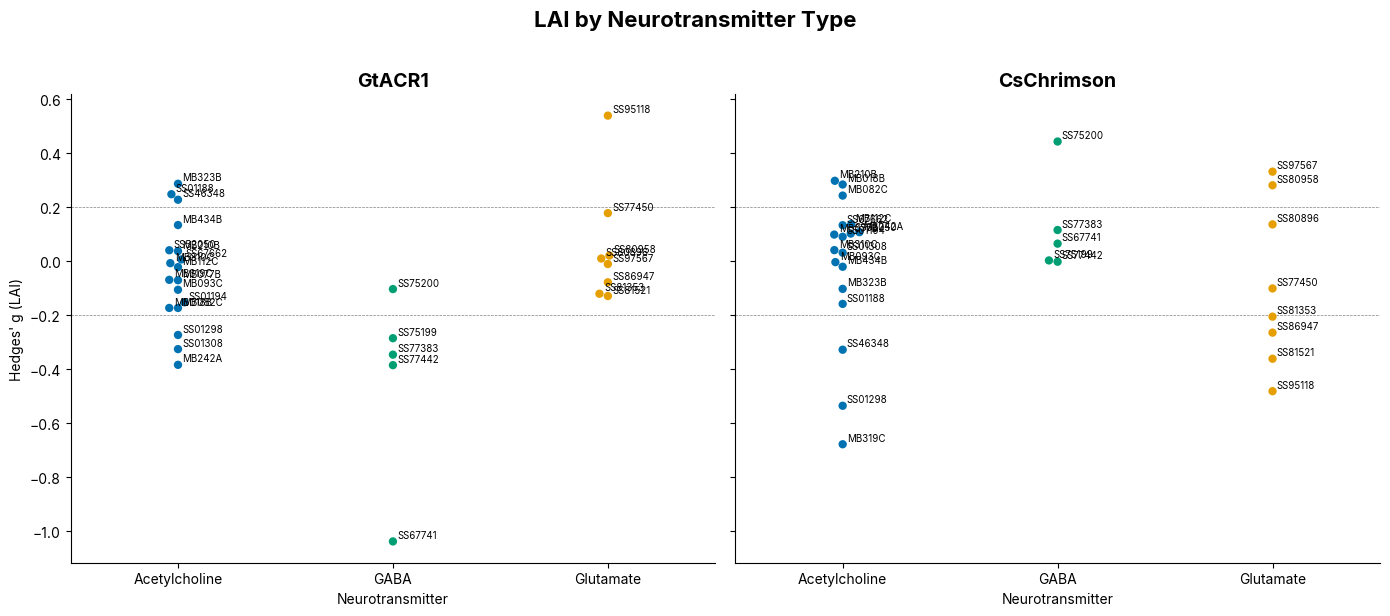

In [16]:
mpl.rcParams['svg.fonttype'] = 'none'

for metric_col, metric_label in [('PI_Hg_OSAR', 'PI'), ('Light Attraction Index_Hg_OSAR', 'LAI')]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey='row')

    for ax, (src, responder_name) in zip(axes, [(acr, 'GtACR1'), (chrimson, 'CsChrimson')]):
        plot_df = pd.DataFrame({
            'MBON': mbons,
            metric_label: src.loc[mbons, metric_col].values,
            'Neurotransmitter': lobelocation.set_index('MBON').loc[mbons, 'Neurotransmitter'].values
        }).reset_index(drop=True)

        n_before = len(ax.collections)
        sns.swarmplot(x='Neurotransmitter', y=metric_label, data=plot_df, s=6, ax=ax, palette=NT_COLORS)
        offsets = np.vstack([c.get_offsets() for c in ax.collections[n_before:]])
        for i, row in plot_df.iterrows():
            ax.annotate(row['MBON'], offsets[i],
                        fontsize=7, ha='left', va='bottom', xytext=(3, 1), textcoords='offset points')

        ax.axhline(-0.2, c=(.5, .5, .5), ls='--', lw=0.5)
        ax.axhline(0.2, c=(.5, .5, .5), ls='--', lw=0.5)
        # ax.axhline(0, c='k', ls='-', lw=0.5)
        ax.set_title(responder_name, weight='bold', fontsize=14)
        ax.set_ylabel(f"Hedges' g ({metric_label})")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle(f'{metric_label} by Neurotransmitter Type', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 2. Phenomics - Pref vs Loco by NT (OSAR only)

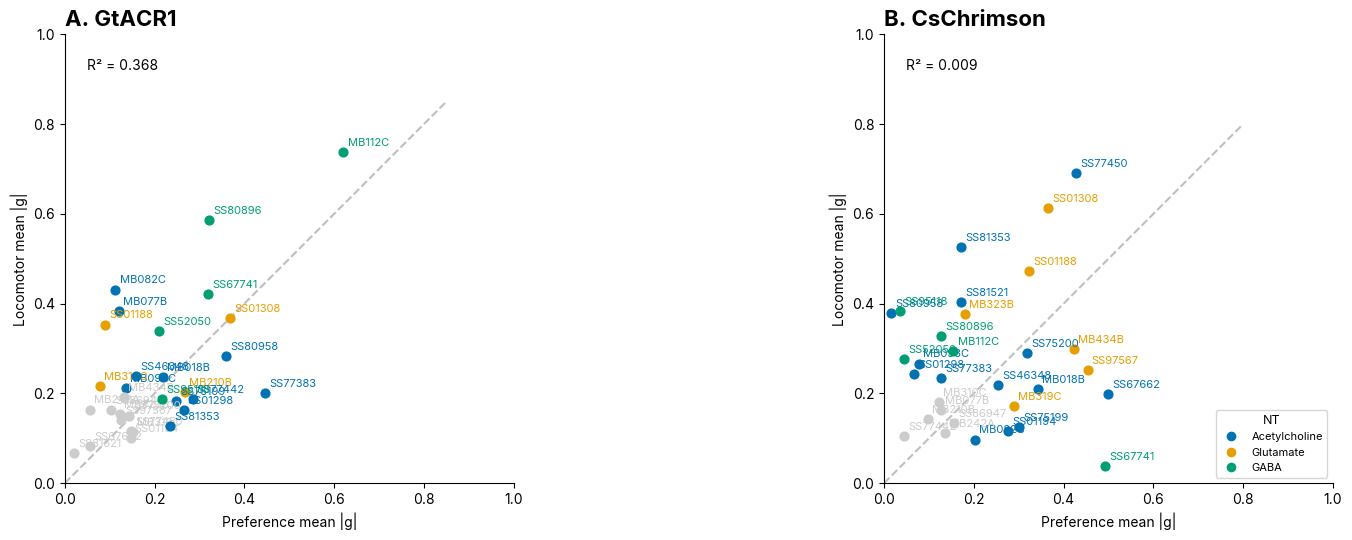

In [15]:
mpl.rcParams['svg.fonttype'] = 'none'

nt_series = lobelocation.set_index('MBON')['Neurotransmitter']

panels = [
    (pref_acr, loco_acr, 'GtACR1'),
    (pref_chr, loco_chr, 'CsChrimson')
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

for ax, (x, y, title), label in zip(axes, panels, ['A', 'B']):
    for mbon in mbons:
        nt = nt_series[mbon]
        if x[mbon] < 0.2 and y[mbon] < 0.2:
            color = '#CCCCCC'
        else:
            color = NT_COLORS.get(nt, '#999999')
        ax.scatter(x[mbon], y[mbon], s=40, color=color, zorder=3)
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points', color=color)

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel('Preference mean |g|', fontsize=10)
    ax.set_ylabel('Locomotor mean |g|', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=NT_COLORS[nt], markersize=8, label=nt) for nt in NT_COLORS]
axes[1].legend(handles=handles, title='NT', fontsize=8, title_fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

## 3. Locomotion only - by NT (OSAR)

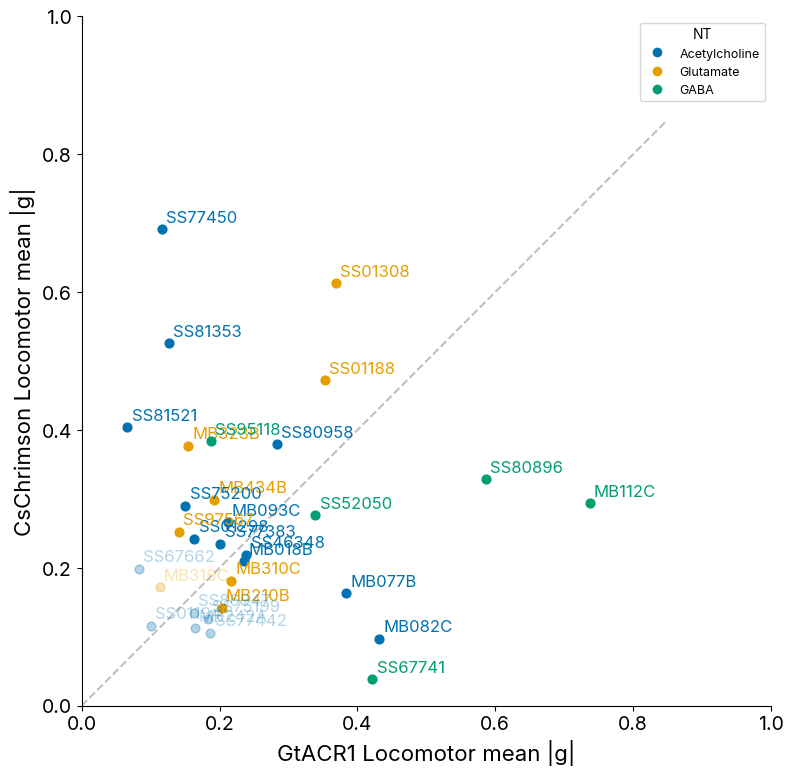

In [12]:
mpl.rcParams['svg.fonttype'] = 'none'

x = loco_acr
y = loco_chr

fig, ax = plt.subplots(figsize=(8, 8))

for mbon in mbons:
    nt = nt_series[mbon]
    alpha = 0.3 if (x[mbon] < 0.2 and y[mbon] < 0.2) else 1.0
    ax.scatter(x[mbon], y[mbon], s=40, color=NT_COLORS.get(nt, '#999999'), zorder=3, alpha=alpha)
    ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=12, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points', color=NT_COLORS.get(nt, '#999999'), alpha=alpha)

lim = max(x.max(), y.max()) * 1.15
ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.0)

ax.set_xlabel('GtACR1 Locomotor mean |g|', fontsize=16)
ax.set_ylabel('CsChrimson Locomotor mean |g|', fontsize=16)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=NT_COLORS[nt], markersize=8, label=nt) for nt in NT_COLORS]
ax.legend(handles=handles, title='NT', fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()

## 4. Combined phenomics (OSAR + Falling) by NT

In [17]:
df_total_raw = pd.read_excel(filepath_total)
df_total_raw = df_total_raw[~df_total_raw['MBON'].isin(['VT999036', 'R76B09'])]

acr_t = df_total_raw[df_total_raw['responder'] == 'ACR'].set_index('MBON')
chr_t = df_total_raw[df_total_raw['responder'] == 'Chrimson2'].set_index('MBON')
mbons_t = acr_t.index.intersection(chr_t.index)
acr_t = acr_t.loc[mbons_t]
chr_t = chr_t.loc[mbons_t]

locomotor_metrics_OSAR = [
    'Log2 Bout Speed ratio_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
    'Bout Number Index_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR',
]
locomotor_metrics_climbing = [
    'Average height climbed_\u0394g_Falling', 'Straightness Index_\u0394g_Falling',
    'Bout speed_\u0394g_Falling', 'Duration of bouts_\u0394g_Falling',
    'Number of Bouts_\u0394g_Falling', 'Max velocity_\u0394g_Falling',
]

osar_acr = acr_t[locomotor_metrics_OSAR].abs().mean(axis=1)
osar_chr = chr_t[locomotor_metrics_OSAR].abs().mean(axis=1)
climb_acr = acr_t[locomotor_metrics_climbing].abs().mean(axis=1)
climb_chr = chr_t[locomotor_metrics_climbing].abs().mean(axis=1)

pref_acr_t = acr_t[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']].abs().mean(axis=1)
pref_chr_t = chr_t[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']].abs().mean(axis=1)

effect_threshold = 0.35
high_acr = (osar_acr >= effect_threshold) | (climb_acr >= effect_threshold)
high_chr = (osar_chr >= effect_threshold) | (climb_chr >= effect_threshold)

lobelocation_t = NLProcessing.generate_lobelocation(mbons_t.tolist(), mbonlist_csv)
nt_series_t = lobelocation_t.set_index('MBON')['Neurotransmitter']

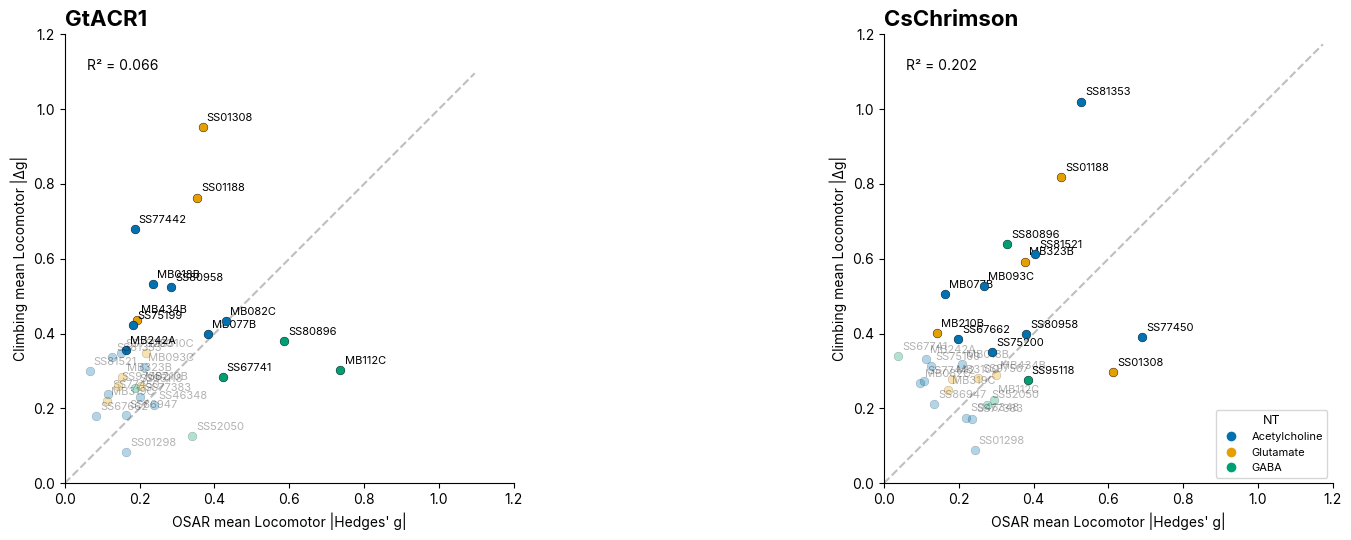

In [14]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (osar_acr, climb_acr, high_acr, 'GtACR1'),
    (osar_chr, climb_chr, high_chr, 'CsChrimson'),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

for ax, (x, y, mask, title), label in zip(axes, panels, ['A', 'B']):
    for mbon in mbons_t:
        nt = nt_series_t[mbon]
        alpha = 1.0 if mask[mbon] else 0.3
        ax.scatter(x[mbon], y[mbon], s=40, color=NT_COLORS.get(nt, '#999999'), zorder=3, alpha=alpha, edgecolors='k', linewidth=0.3)
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points', alpha=alpha)

    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel("OSAR mean Locomotor |Hedges' g|", fontsize=10)
    ax.set_ylabel('Climbing mean Locomotor |\u0394g|', fontsize=10)
    ax.set_title(f'{title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=NT_COLORS[nt], markersize=8, label=nt) for nt in NT_COLORS]
axes[1].legend(handles=handles, title='NT', fontsize=8, title_fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

# Heatmaps

In [4]:
import textwrap

responder = 'ACR'  # Switch to 'ACR' as needed

totalmetriccomparison = pd.read_excel(filepath)

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'coolwarm'
elif responder == 'ACR':
    responderrename = "GtACR1"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colormap = 'coolwarm'

df_cluster = df_cluster[~df_cluster['MBON'].isin(['VT999036', 'R76B09'])]


lobelocation_cluster = NLProcessing.generate_lobelocation(df_cluster['MBON'].tolist(), mbonlist_csv)
for n in df_cluster['MBON']:
    df_cluster.loc[df_cluster['MBON'] == n, 'Lobe'] = lobelocation_cluster[lobelocation_cluster['MBON'] == n]['Lobe_location'].values[0]
    df_cluster.loc[df_cluster['MBON'] == n, 'Name'] = lobelocation_cluster[lobelocation_cluster['MBON'] == n]['MBON number'].values[0]
    df_cluster.loc[df_cluster['MBON'] == n, 'NT'] = lobelocation_cluster[lobelocation_cluster['MBON'] == n]['Neurotransmitter'].values[0]

df_cluster_data = df_cluster.drop(columns=['responder', 'Lobe', 'NT', 'Name', 'MBON']).copy()
df_cluster_data.index = df_cluster['MBON']

def shorten_mbon_numbers(mbon_str):
    if pd.isna(mbon_str) or mbon_str == '':
        return mbon_str
    parts = [p.strip() for p in mbon_str.split(',')]
    if len(parts) <= 1:
        return mbon_str
    return ', '.join([parts[0]] + [p.replace('MBON', '').strip() for p in parts[1:]])

def parse_nt(nt_str):
    if pd.isna(nt_str) or nt_str == '':
        return ['Unknown']
    nts = [x.strip() for x in nt_str.split(',')]
    return nts if nts else ['Unknown']

def parse_lobes(lobe_str):
    if pd.isna(lobe_str) or lobe_str == '':
        return ['Unknown']
    lobe_str_lower = lobe_str.lower()
    lobes = []
    if 'calyx' in lobe_str_lower: lobes.append('Calyx')
    if "α'" in lobe_str or "a'" in lobe_str_lower: lobes.append("α'")
    if "β'" in lobe_str or "b'" in lobe_str_lower: lobes.append("β'")
    if any(c in lobe_str_lower for c in ['a1', 'a2', 'a3', 'α1', 'α2', 'α3']) and "α'" not in lobes: lobes.append('α')
    if any(c in lobe_str_lower for c in ['b1', 'b2', 'b3', 'β1', 'β2', 'β3']) and "β'" not in lobes: lobes.append('β')
    if any(c in lobe_str_lower for c in ['y1', 'y2', 'y3', 'y4', 'y5', 'γ1', 'γ2', 'γ3', 'γ4', 'γ5']): lobes.append('γ')
    return lobes if lobes else ['Unknown']

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width, break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0, ha='center')

df_cluster['Name_short'] = df_cluster['Name'].apply(shorten_mbon_numbers)
df_cluster['NT_parsed'] = df_cluster['NT'].apply(parse_nt)
df_cluster['Lobes_parsed'] = df_cluster['Lobe'].apply(parse_lobes)

nt_palette = {
    'Acetylcholine': '#0072B2',
    'Glutamate': "#FFCD27",
    'GABA': '#009E73',
}

lobe_palette = {'α': "#E60000", "α'": "#F576CB", 'β': "#723D01", "β'": "#B86800", 'γ': '#999999', 'Calyx': '#000000', 'Unknown': '#FFFFFF'}

# Settings
fig_width, fig_height = 5, 10
dendrogram_size = 0.08
gap = 0.02

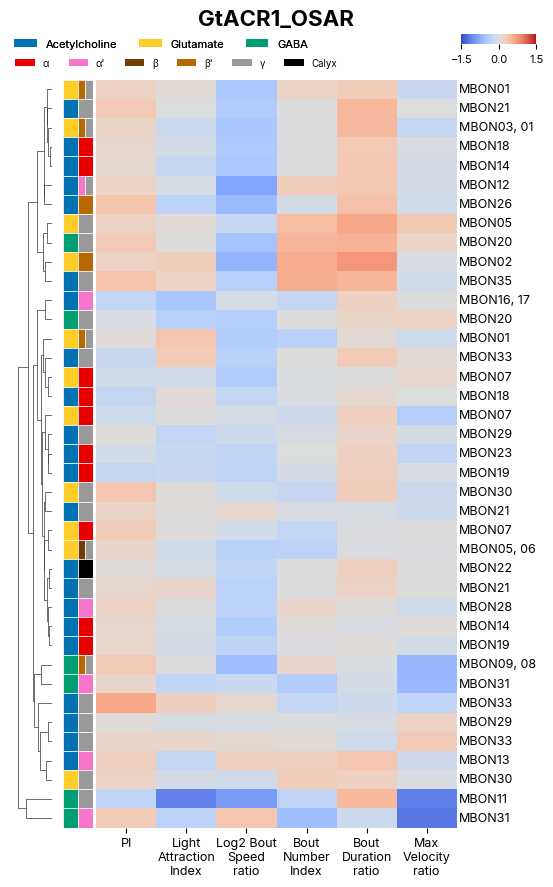

In [11]:
plt.rcParams["font.family"] = "Inter"

df_clusternew = df_cluster_data[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR',
       'Log2 Bout Speed ratio_Hg_OSAR', 
       'Bout Number Index_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
       'Max Velocity ratio_Hg_OSAR']]

g1 = sns.clustermap(df_clusternew, cmap=colormap, method='complete', metric='euclidean', 
                    yticklabels=False, xticklabels=[col.replace("_Hg_OSAR", "") for col in df_clusternew.columns], vmin=-1.5, vmax=1.5,
                    row_cluster=True, col_cluster=False, annot=False,
                    row_colors=['#FFFFFF'] * len(df_clusternew),
                    dendrogram_ratio=(dendrogram_size, dendrogram_size),
                    cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]), 
                    figsize=(fig_width, fig_height), cbar_pos=(0.92, 0.955, 0.15, 0.010))

cbar = g1.ax_cbar
cbar.tick_params(labelsize=8)

row_order = g1.dendrogram_row.reordered_ind
rc_pos = g1.ax_row_colors.get_position()
hm_pos = g1.ax_heatmap.get_position()
col_w = 0.03

g1.ax_row_colors.set_position([rc_pos.x0 + gap, rc_pos.y0, col_w * 2, rc_pos.height])
g1.ax_heatmap.set_position([hm_pos.x0 + gap + col_w*2 - 0.02, hm_pos.y0, hm_pos.width - col_w*2-0.02, hm_pos.height])

ax_rc = g1.ax_row_colors
ax_rc.clear()
ax_rc.set_xlim(0, 2)
ax_rc.set_ylim(0, len(row_order))
ax_rc.invert_yaxis()
ax_rc.axis('off')

for i, idx in enumerate(row_order):
    nts = df_cluster['NT_parsed'].iloc[idx]
    n_nts = len(nts) if nts else 1
    for j, nt in enumerate(nts):
        rect = plt.Rectangle((j / n_nts, i), 1 / n_nts, 1, facecolor=nt_palette.get(nt, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_rc.add_patch(rect)
    lobes = df_cluster['Lobes_parsed'].iloc[idx]
    n_lobes = len(lobes) if lobes else 1
    for j, lobe in enumerate(lobes):
        rect = plt.Rectangle((1 + j / n_lobes, i), 1 / n_lobes, 1, facecolor=lobe_palette.get(lobe, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_rc.add_patch(rect)

g1.ax_heatmap.set_ylabel('')
g1.ax_heatmap.set_xticklabels(g1.ax_heatmap.get_xticklabels(), ha='center', fontsize=9)
wrap_labels(g1.ax_heatmap, 10)

for i, idx in enumerate(row_order):
    g1.ax_heatmap.text(1.005, i + 0.5, df_cluster['Name_short'].iloc[idx], ha='left', va='center', fontsize=9, transform=g1.ax_heatmap.get_yaxis_transform())

nt_legend = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor=None, label=l) for l, c in nt_palette.items()]
lobe_legend = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor=None, label=l) for l, c in lobe_palette.items() if l != 'Unknown']
leg1 = g1.fig.legend(handles=nt_legend, loc='upper center', bbox_to_anchor=(0.32, 0.97), ncol=len(nt_legend), fontsize=8, title_fontsize=10, frameon=False)
g1.fig.add_artist(leg1)
g1.fig.legend(handles=lobe_legend, loc='upper center', bbox_to_anchor=(0.35, 0.95), ncol=len(lobe_legend), fontsize=7, title_fontsize=10, frameon=False)

g1.fig.suptitle(responderrename+ "_OSAR", fontsize=16, x=0.55, y=0.99, fontweight = 'bold')
mpl.rcParams['svg.fonttype'] = 'none'
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "_clustermapofmbonsbynttypeandlobe_OSAR_" + responder + ".svg", bbox_inches="tight")
plt.show()

In [11]:
# Falling clustermap setup
responder_fall = 'Chrimson2'  # Switch to 'ACR' as needed

filepath_falling = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling_20260423.xlsx"
totalmetriccomparison_fall = pd.read_excel(filepath_falling)

if responder_fall == 'Chrimson2':
    responderrename_fall = "CsChrimson"
    df_cluster_fall = totalmetriccomparison_fall[totalmetriccomparison_fall['responder']=="Chrimson2"].reset_index(drop=True)
    colormap_fall = 'coolwarm'
elif responder_fall == 'ACR':
    responderrename_fall = "GtACR1"
    df_cluster_fall = totalmetriccomparison_fall[totalmetriccomparison_fall['responder']=="ACR"].reset_index(drop=True)
    colormap_fall = 'coolwarm'

df_cluster_fall = df_cluster_fall[~df_cluster_fall['MBON'].isin(['VT999036', 'R76B09'])]

lobelocation_fall = NLProcessing.generate_lobelocation(df_cluster_fall['MBON'].tolist(), mbonlist_csv)
for n in df_cluster_fall['MBON']:
    df_cluster_fall.loc[df_cluster_fall['MBON'] == n, 'Lobe'] = lobelocation_fall[lobelocation_fall['MBON'] == n]['Lobe_location'].values[0]
    df_cluster_fall.loc[df_cluster_fall['MBON'] == n, 'Name'] = lobelocation_fall[lobelocation_fall['MBON'] == n]['MBON number'].values[0]
    df_cluster_fall.loc[df_cluster_fall['MBON'] == n, 'NT'] = lobelocation_fall[lobelocation_fall['MBON'] == n]['Neurotransmitter'].values[0]

df_cluster_data_fall = df_cluster_fall.drop(columns=['genotypeandresponder', 'responder', 'Lobe', 'NT', 'Name', 'MBON']).copy()
df_cluster_data_fall.index = df_cluster_fall['MBON']

df_cluster_fall['Name_short'] = df_cluster_fall['Name'].apply(shorten_mbon_numbers)
df_cluster_fall['NT_parsed'] = df_cluster_fall['NT'].apply(parse_nt)
df_cluster_fall['Lobes_parsed'] = df_cluster_fall['Lobe'].apply(parse_lobes)
df_cluster_fall2 = df_cluster_fall.copy()

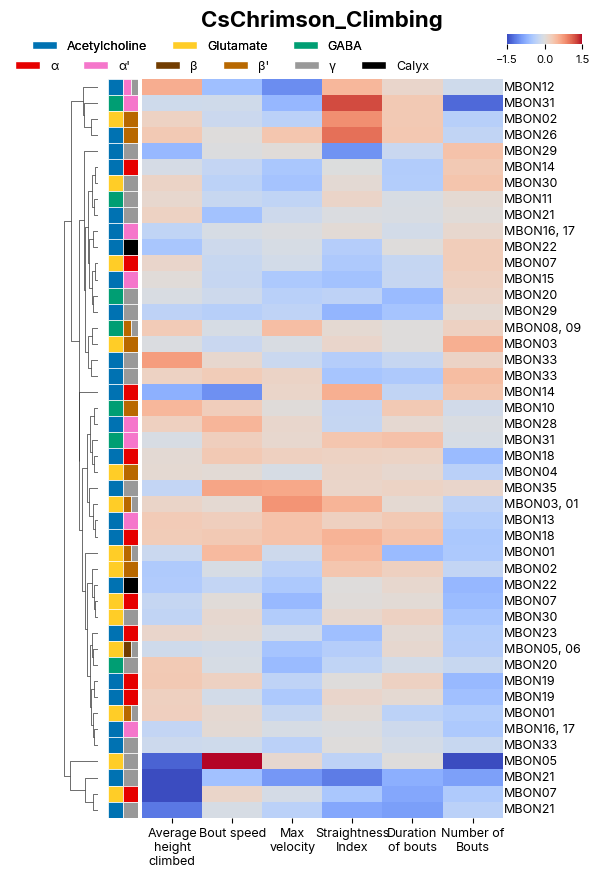

In [12]:
plt.rcParams["font.family"] = "Inter"

df_cluster_fall2 = df_cluster_fall2[['MBON', 'Average height climbed_Δg',
       'Bout speed_Δg', 'Max velocity_Δg','Straightness Index_Δg', 'Duration of bouts_Δg', 'Number of Bouts_Δg','responder', 'genotypeandresponder', 'Lobe',
       'Name', 'NT', 'Name_short', 'NT_parsed', 'Lobes_parsed']]

df_cluster_fall_numeric = df_cluster_fall2[['Average height climbed_Δg',
       'Bout speed_Δg', 'Max velocity_Δg','Straightness Index_Δg', 'Duration of bouts_Δg', 'Number of Bouts_Δg']]
df_cluster_fall_numeric.index = df_cluster_fall2['MBON']

g1 = sns.clustermap(df_cluster_fall_numeric, cmap=colormap, method='complete', metric='euclidean', yticklabels=False, 
                    xticklabels=[col.replace("_Δg", "").replace("_ΔΔ", "") for col in df_cluster_fall_numeric.columns], vmin=-1.5, vmax=1.5,
                    row_cluster=True, col_cluster=False, annot=False,
                    row_colors=['#FFFFFF'] * len(df_cluster_fall_numeric),
                    dendrogram_ratio=(dendrogram_size, dendrogram_size),
                    cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]), 
                    figsize=(fig_width, fig_height), cbar_pos=(0.92, 0.955, 0.15, 0.010))

cbar = g1.ax_cbar
cbar.tick_params(labelsize=8)

row_order = g1.dendrogram_row.reordered_ind
rc_pos = g1.ax_row_colors.get_position()
hm_pos = g1.ax_heatmap.get_position()
col_w = 0.03

g1.ax_row_colors.set_position([rc_pos.x0 + gap, rc_pos.y0, col_w * 2, rc_pos.height])
g1.ax_heatmap.set_position([hm_pos.x0 + gap + col_w*2 - 0.02, hm_pos.y0, hm_pos.width - col_w*2-0.02, hm_pos.height])

ax_rc = g1.ax_row_colors
ax_rc.clear()
ax_rc.set_xlim(0, 2)
ax_rc.set_ylim(0, len(row_order))
ax_rc.invert_yaxis()
ax_rc.axis('off')

for i, idx in enumerate(row_order):
    nts = df_cluster_fall2['NT_parsed'].iloc[idx]
    n_nts = len(nts) if nts else 1
    for j, nt in enumerate(nts):
        rect = plt.Rectangle((j / n_nts, i), 1 / n_nts, 1, facecolor=nt_palette.get(nt, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_rc.add_patch(rect)
    lobes = df_cluster_fall2['Lobes_parsed'].iloc[idx]
    n_lobes = len(lobes) if lobes else 1
    for j, lobe in enumerate(lobes):
        rect = plt.Rectangle((1 + j / n_lobes, i), 1 / n_lobes, 1, facecolor=lobe_palette.get(lobe, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_rc.add_patch(rect)

g1.ax_heatmap.set_ylabel('')
g1.ax_heatmap.set_xticklabels(g1.ax_heatmap.get_xticklabels(), ha='center', fontsize=9)
wrap_labels(g1.ax_heatmap, 10)

for i, idx in enumerate(row_order):
    g1.ax_heatmap.text(1.005, i + 0.5, df_cluster_fall2['Name_short'].iloc[idx], ha='left', va='center', fontsize=9, transform=g1.ax_heatmap.get_yaxis_transform())

nt_legend = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white', label=l) for l, c in nt_palette.items()]
lobe_legend = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white', label=l) for l, c in lobe_palette.items() if l != 'Unknown']
leg1 = g1.fig.legend(handles=nt_legend, loc='upper center', bbox_to_anchor=(0.30, 0.97), ncol=len(nt_legend), fontsize=9, title_fontsize=9, frameon=False)
g1.fig.add_artist(leg1)
g1.fig.legend(handles=lobe_legend, loc='upper center', bbox_to_anchor=(0.35, 0.95), ncol=len(lobe_legend), fontsize=9, title_fontsize=8, frameon=False)

g1.fig.suptitle(responderrename_fall+ "_Climbing", fontsize=16, x=0.55, y=0.99, fontweight = 'bold')
mpl.rcParams['svg.fonttype'] = 'none'
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "_clustermapofmbonsbynttype_Climbing_" + responder_fall + ".svg", bbox_inches="tight")
plt.show()